# import libraries

In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import random

os.environ["PYTHONHASHSEED"] = "42"
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.utils import shuffle
import os
import shutil
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

brainrot_path = '/kaggle/input/brainrot/Brainrot/Brainrot'
nonbrainrot_path = '/kaggle/input/brainrot/NonBrainrot/NonBrainrot'
extra_path = "/kaggle/input/extravideos"

IMG_SIZE = 224      
MAX_FRAMES = 60

/usr/local/lib/python3.12/site-packages/jax/_src/cloud_tpu_init.py:93: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [2]:
# combined 2 dataset to balance the data
nonbrainrot_path = "/kaggle/input/brainrot/NonBrainrot/NonBrainrot"
extra_path      = "/kaggle/input/extravideos"

non_brainrot2 = "/kaggle/working/non_brainrot2"

# reset folder to avoid duplicates across reruns
if os.path.exists(non_brainrot2):
    shutil.rmtree(non_brainrot2)
os.makedirs(non_brainrot2)

# copy original non-brainrot
for filename in os.listdir(nonbrainrot_path):
    src = os.path.join(nonbrainrot_path, filename)
    dst = os.path.join(non_brainrot2, filename)
    if os.path.isfile(src):
        shutil.copy(src, dst)

# copy extra videos (rename if name already exists)
for filename in os.listdir(extra_path):
    src = os.path.join(extra_path, filename)
    dst = os.path.join(non_brainrot2, filename)

    if os.path.exists(dst):
        base, ext = os.path.splitext(filename)
        dst = os.path.join(non_brainrot2, f"{base}_extra{ext}")

    if os.path.isfile(src):
        shutil.copy(src, dst)

print(f"Combined dataset is ready at {non_brainrot2}")
print("Total files:", len(os.listdir(non_brainrot2)))


Combined dataset is ready at /kaggle/working/non_brainrot2
Total files: 166


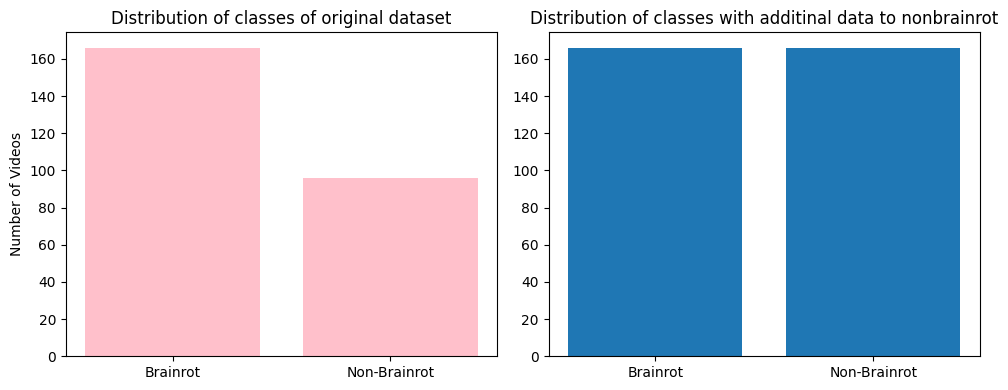

In [3]:
# count videos (original)
brainrot_orig = len([f for f in os.listdir(brainrot_path) if f.endswith(('.mp4','.avi','.mov'))])
nonbrainrot_orig = len([f for f in os.listdir(nonbrainrot_path) if f.endswith(('.mp4','.avi','.mov'))])

# count videos (after adding extra data)
brainrot_final = brainrot_orig
nonbrainrot_final = len([f for f in os.listdir(non_brainrot2) if f.endswith(('.mp4','.avi','.mov'))])

# data for plotting
labels = ['Brainrot', 'Non-Brainrot']
original = [brainrot_orig, nonbrainrot_orig]
final = [brainrot_final, nonbrainrot_final]

# plot
plt.figure(figsize=(10,4))

plt.subplot(1, 2, 1)
plt.bar(labels, original, color = 'pink')
plt.title("Distribution of classes of original dataset")
plt.ylabel("Number of Videos")

plt.subplot(1, 2, 2)
plt.bar(labels, final)
plt.title("Distribution of classes with additinal data to nonbrainrot")

plt.tight_layout()
plt.show()

# Feature Extraction

In [4]:
# Use pre trained model EfficientNetB0 for feature extraction
def build_feature_extractor():
    feature_extractor = keras.applications.EfficientNetB0(
        weights="imagenet",
        include_top=False,
        pooling="avg",
        input_shape=(IMG_SIZE, IMG_SIZE, 3),
    )
    
    preprocess_input = keras.applications.efficientnet.preprocess_input
    
    inputs = keras.Input((IMG_SIZE, IMG_SIZE, 3))
    preprocessed = preprocess_input(inputs)
    outputs = feature_extractor(preprocessed)
    
    return keras.Model(inputs, outputs, name="feature_extractor")


feature_extractor = build_feature_extractor()
print("Feature Extractor Ready. Input Shape:", (IMG_SIZE, IMG_SIZE, 3))

2025-12-13 00:32:53.148188: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Feature Extractor Ready. Input Shape: (224, 224, 3)


# Extract frames/ Data augmentation

In [5]:
# extract frames from videos
def extract_frames(path, max_frames=60, resize=(224, 224)):
    cap = cv2.VideoCapture(path)
    if not cap.isOpened(): return None
    
    frames = []
    try:
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames > max_frames:
            indices = np.linspace(0, total_frames-1, max_frames).astype(int)
        else:
            indices = np.arange(total_frames)

        for i in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, i)
            ret, frame = cap.read()
            if ret:
                frame = cv2.resize(frame, resize)
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                frames.append(frame)
    finally:
        cap.release()

    if len(frames) == 0: return None
    return np.array(frames)

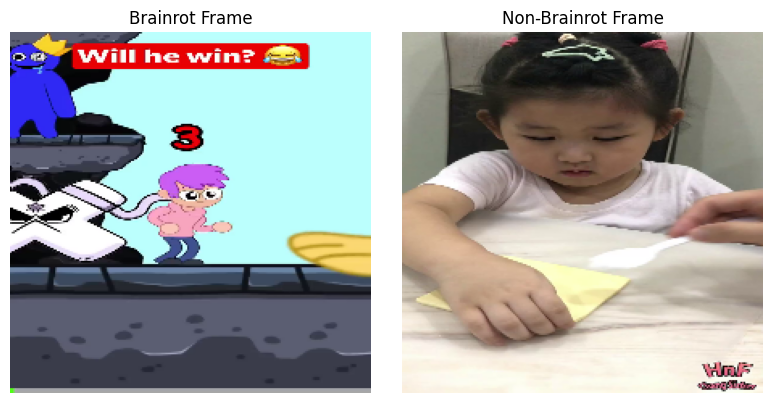

In [6]:
# Display a sample extracted frame from brainrot and nonbrainrot
frames_brain = extract_frames(brainrot_path + "/" + os.listdir(brainrot_path)[0])
frames_non = extract_frames(non_brainrot2 + "/" + os.listdir(non_brainrot2)[0])

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(frames_brain[0])
plt.title("Brainrot Frame")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(frames_non[0])
plt.title("Non-Brainrot Frame")
plt.axis('off')

plt.tight_layout()
plt.show()

In [7]:
# extract videos from folder sequentially
def extract_from_folder_serial(folder_path, label, max_frames=60):
    files = sorted(os.listdir(folder_path))
    video_files = [os.path.join(folder_path, f) for f in files if f.lower().endswith((".mp4", ".avi", ".mov"))]
    
    data = []
    labels = []
    
    print(f"Processing {len(video_files)} videos from {folder_path}...")
    
    for path in video_files:
        frames = extract_frames(path, max_frames=max_frames, resize=(IMG_SIZE, IMG_SIZE))
        
        if frames is not None and len(frames) > 0:
           
            feats = feature_extractor.predict(frames, verbose=0)
            if len(feats) < max_frames:
                diff = max_frames - len(feats)
                feats = np.concatenate((feats, np.zeros((diff, 1280))), axis=0)
            data.append(feats)
            labels.append(label)
            # Apply data augmentation
            # flip the farme horiziontali
            frames_flipped = np.flip(frames, axis=2)
            feats_flipped = feature_extractor.predict(frames_flipped, verbose=0)
            if len(feats_flipped) < max_frames:
                diff = max_frames - len(feats_flipped)
                feats_flipped = np.concatenate((feats_flipped, np.zeros((diff, 1280))), axis=0)
            data.append(feats_flipped)
            labels.append(label)

    return np.array(data), np.array(labels)

In [8]:
# Extract frames from both sets
X_brain, y_brain = extract_from_folder_serial(brainrot_path, label=1)
X_non, y_non = extract_from_folder_serial(non_brainrot2, label=0)


X = np.concatenate([X_brain, X_non], axis=0)
y = np.concatenate([y_brain, y_non], axis=0)

# Shuffle the data 
X, y = shuffle(X, y, random_state=42)

print(f"Final Data Shape: {X.shape}") 

Processing 166 videos from /kaggle/input/brainrot/Brainrot/Brainrot...


[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e34e43e00] mmco: unref short failure
[h264 @ 0x5a2e366eaec0] mmco: unref short failure
[h264 @ 0x5a2e366eaec0] mmco: unref short failure
[h264 @ 0x5a2e399aea80] mmco: unref short failure
[h264 @ 0x5a2e399aea80] mmco: unref short failure
[h264 @ 0x5a2e399aea80] mmco: unref short failure
[h264 @ 0x5a2e399aea80] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure
[h264 @ 0x5a2e39b16600] mmco: unref short failure


Processing 166 videos from /kaggle/working/non_brainrot2...


[h264 @ 0x5a2e3c259480] mmco: unref short failure
[h264 @ 0x5a2e3c259480] mmco: unref short failure
[h264 @ 0x5a2e3a14dd80] mmco: unref short failure
[h264 @ 0x5a2e3d8a6080] mmco: unref short failure
[h264 @ 0x5a2e39d71d00] mmco: unref short failure
[h264 @ 0x5a2e39d71d00] mmco: unref short failure
[h264 @ 0x5a2e3c256fc0] mmco: unref short failure
[h264 @ 0x5a2e3c256fc0] mmco: unref short failure
[h264 @ 0x5a2e3c256fc0] mmco: unref short failure
[h264 @ 0x5a2e3c256fc0] mmco: unref short failure
[h264 @ 0x5a2e3a146a80] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure
[h264 @ 0x5a2e394c0500] mmco: unref short failure


Final Data Shape: (664, 60, 1280)


# Split train/validation, test

In [9]:
# split train/test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15,       
    stratify=y,          
    random_state=42
)
# split train/validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=0.176,     
    stratify=y_temp, 
    random_state=42
)

# compute class weights
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(class_weights))
print("Training Data Shape:", X_train.shape)

Training Data Shape: (464, 60, 1280)


# Build model

In [10]:
#build GRU model
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(MAX_FRAMES, 1280)),
        layers.Masking(mask_value=0.0),
        layers.GRU(64, return_sequences=False, 
                   kernel_regularizer=regularizers.l2(0.01),
                   recurrent_regularizer=regularizers.l2(0.01)),        
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(2, activation="softmax", kernel_regularizer=regularizers.l2(0.01))
    ])
    
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model

model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ masking (Masking)               │ (None, 60, 1280)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 64)             │       258,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 258,818 (1011.01 KB)

 Trainable params: 258,690 (1010.51 KB)

 Non-trainable params: 128 (512.00 B)

# Training model

In [24]:
# Train model using K-fold method
k = 2 # folds
skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
fold_val_accuracies = []
fold_val_losses = []

fold_histories = []

print(f"Starting {k}-Fold Cross-Validation on X_temp...")

for fold, (train_index, val_index) in enumerate(skf.split(X_temp, y_temp)):
    print(f"\n--- Fold {fold+1}/{k} ---")
    
    # Split data for the current fold
    X_train_fold, X_val_fold = X_temp[train_index], X_temp[val_index]
    y_train_fold, y_val_fold = y_temp[train_index], y_temp[val_index]
    
    # Get a fresh, un-trained model for this fold
    fold_model = build_model()
    
    # Define Callbacks 
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)
    ]
    
    # Train the model for this fold
    fold_model.fit(
        X_train_fold, y_train_fold,
        validation_data=(X_val_fold, y_val_fold),
        epochs=30,
        batch_size=16,
        class_weight=class_weights_dict,
        callbacks=callbacks,
        verbose=0  
    )
    
    # Evaluate the model on the current fold's validation set
    loss, accuracy = fold_model.evaluate(X_val_fold, y_val_fold, verbose=0)
    print(f"Fold {fold+1} Validation Accuracy: {accuracy:.2%}")
    
    fold_val_accuracies.append(accuracy)
    fold_val_losses.append(loss)

    fold_histories.append(history.history)

# Calculate and report the final average metrics
avg_accuracy = np.mean(fold_val_accuracies)
avg_loss = np.mean(fold_val_losses)

print("\n" + "="*60)
print(f"FINAL K-FOLD CROSS-VALIDATION RESULTS ({k} Folds on Temp Data)")
print(f"Average Validation Accuracy: {avg_accuracy:.2%}")
print(f"Average Validation Loss: {avg_loss:.4f}")
print("="*60)

Starting 2-Fold Cross-Validation on X_temp...

--- Fold 1/2 ---
Fold 1 Validation Accuracy: 94.68%

--- Fold 2/2 ---
Fold 2 Validation Accuracy: 95.04%

FINAL K-FOLD CROSS-VALIDATION RESULTS (2 Folds on Temp Data)
Average Validation Accuracy: 94.86%
Average Validation Loss: 0.7250


In [25]:
print("Re-training final model on combined train/val data (X_temp)...")

callbacks = [
    keras.callbacks.EarlyStopping(monitor='loss', patience=15, restore_best_weights=True), # Monitor training loss for this final run
    keras.callbacks.ReduceLROnPlateau(monitor='loss', factor=0.5, patience=5)
]

# Train on the entire combined training/validation set (X_temp, y_temp)
history_final = model.fit(
    X_temp, y_temp, 
    epochs=20,
    batch_size=16,
    class_weight=class_weights_dict,
    callbacks=callbacks
)

Re-training final model on combined train/val data (X_temp)...
Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9823 - loss: 0.2184 - learning_rate: 0.0010
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9787 - loss: 0.2129 - learning_rate: 0.0010
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9947 - loss: 0.1831 - learning_rate: 0.0010
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9947 - loss: 0.1620 - learning_rate: 0.0010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9929 - loss: 0.1592 - learning_rate: 0.0010
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9947 - loss: 0.1478 - learning_rate: 0.0010
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9947 - loss: 0.1568 - learning_rate: 0.0010
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9894 - loss: 0.1659 - learning_rate: 0.0010
Epoch 9/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.

# Model Evaluation 

Evaluating on Test Set...

 Final Test Accuracy: 98.00%
 Final Test Loss: 0.1759
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

 Classification Report:
              precision    recall  f1-score   support

Non-Brainrot       1.00      0.96      0.98        50
    Brainrot       0.96      1.00      0.98        50

    accuracy                           0.98       100
   macro avg       0.98      0.98      0.98       100
weighted avg       0.98      0.98      0.98       100



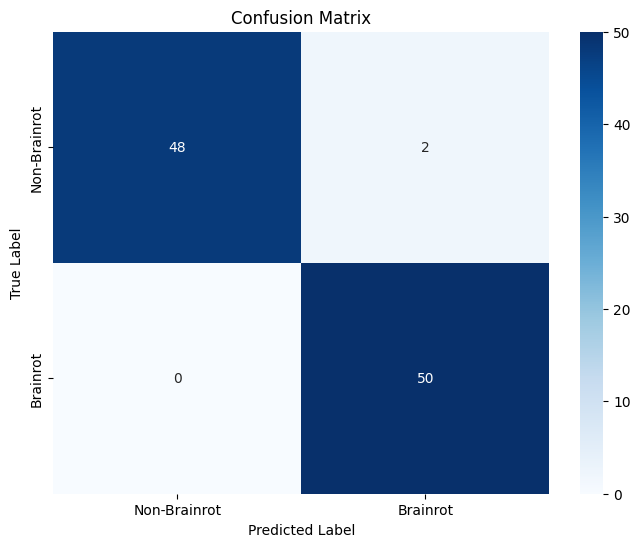

In [26]:
print("Evaluating on Test Set...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\n Final Test Accuracy: {test_acc:.2%}")
print(f" Final Test Loss: {test_loss:.4f}")


y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1) 


print("\n Classification Report:")
target_names = ['Non-Brainrot', 'Brainrot']
print(classification_report(y_test, y_pred, target_names=target_names))


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, 
            yticklabels=target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

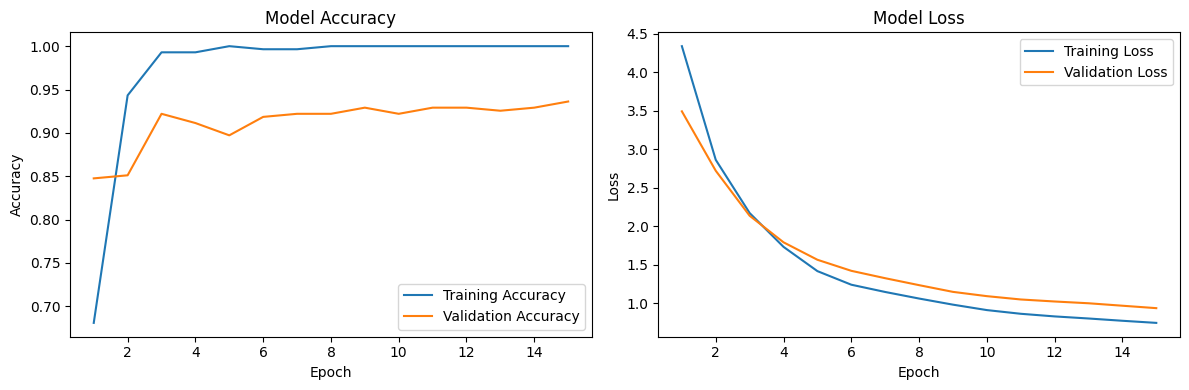

In [27]:
# plotting ROC

epochs = len(fold_histories[0]['loss'])

avg_train_acc = np.mean([h['accuracy'] for h in fold_histories], axis=0)
avg_val_acc   = np.mean([h['val_accuracy'] for h in fold_histories], axis=0)
avg_train_loss= np.mean([h['loss'] for h in fold_histories], axis=0)
avg_val_loss  = np.mean([h['val_loss'] for h in fold_histories], axis=0)

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(range(1, epochs+1), avg_train_acc, label='Training Accuracy')
plt.plot(range(1, epochs+1), avg_val_acc, label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, epochs+1), avg_train_loss, label='Training Loss')
plt.plot(range(1, epochs+1), avg_val_loss, label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()



# Predict on external data

In [28]:
def predict_new_video(video_path):
    print(f"Testing video: {video_path}")
    
    frames = extract_frames(video_path, max_frames=60, resize=(224, 224))
    if frames is None:
        print("Error: Could not read video or video is empty.")
        return
    
    feats = feature_extractor.predict(frames, verbose=0)
    
    if len(feats) < 60:
        diff = 60 - len(feats)
        padding = np.zeros((diff, 1280)) 
        feats = np.concatenate((feats, padding), axis=0)
    
    feats = np.expand_dims(feats, axis=0)
    
    predictions = model.predict(feats)
    
    class_idx = np.argmax(predictions[0])
    confidence = predictions[0][class_idx]
    
    result = "Brainrot" if class_idx == 1 else "Non-Brainrot"
    
    print(f"Result: {result}")
    print(f"Confidence: {confidence:.2%}\n")
    print("-" * 30)
    
    return result, confidence


In [29]:
test1 = "/kaggle/input/prediction/Skincare_tutorial.mp4" #Non brainrot
predict_new_video(test1)

Testing video: /kaggle/input/prediction/Skincare_tutorial.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Result: Non-Brainrot
Confidence: 93.26%

------------------------------


('Non-Brainrot', np.float32(0.9325778))

In [31]:
test2="/kaggle/input/prediction/Arabic long division explaination.mp4" #Non brainrot
predict_new_video(test2)

Testing video: /kaggle/input/prediction/Arabic long division explaination.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Result: Non-Brainrot
Confidence: 78.69%

------------------------------


('Non-Brainrot', np.float32(0.7868977))

In [32]:
test3="/kaggle/input/prediction/tiktokvideo.MP4" # brainrot
predict_new_video(test3)

Testing video: /kaggle/input/prediction/tiktokvideo.MP4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Result: Brainrot
Confidence: 99.76%

------------------------------


('Brainrot', np.float32(0.9975541))

In [34]:
test4="/kaggle/input/prediction/ballrena cappucina.MP4" # brainrot
predict_new_video(test4)

Testing video: /kaggle/input/prediction/ballrena cappucina.MP4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Result: Non-Brainrot
Confidence: 99.10%

------------------------------


('Non-Brainrot', np.float32(0.99095696))

In [35]:
test5 = "/kaggle/input/prediction/pythontutorial.mp4"#Non brainrot
predict_new_video(test5)

Testing video: /kaggle/input/prediction/pythontutorial.mp4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Result: Non-Brainrot
Confidence: 54.92%

------------------------------


('Non-Brainrot', np.float32(0.5491789))

In [36]:
test7="/kaggle/input/prediction/Gilmore2.MP4"#Non brainrot
predict_new_video(test7)

Testing video: /kaggle/input/prediction/Gilmore2.MP4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Result: Non-Brainrot
Confidence: 82.97%

------------------------------


('Non-Brainrot', np.float32(0.82968974))